# **Install Required Libraries**

In [49]:
from google.colab import files

In [50]:
!pip install xgboost

# **Import Libraries**

In [51]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import matplotlib.pyplot as plt

# **Load Dataset**

In [52]:
df = pd.read_csv("EV_Charging_Load_Demand_Dataset.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33708 entries, 0 to 33707
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   timestep_sec                      33708 non-null  float64
 1   minute_of_hour                    33708 non-null  int64  
 2   vehicle_id                        33708 non-null  object 
 3   speed_ms                          33708 non-null  float64
 4   acceleration_ms2                  33708 non-null  float64
 5   soc_percent                       33708 non-null  float64
 6   energy_consumed_Wh                33708 non-null  float64
 7   lane_id                           33708 non-null  object 
 8   status                            33708 non-null  object 
 9   current_station_id                33708 non-null  object 
 10  station_load_kW                   33708 non-null  int64  
 11  station_vehicles_charging         33708 non-null  int64  
 12  stat

# **Handle Missing Values**

**Only lane_id has missing values**

In [53]:
# df['lane_id'] = df['lane_id'].fillna('unknown')

**Remove Leakage + Noise**

In [54]:
# Remove direct leakage
df = df.drop(columns=['station_load_kW'])

# Remove noisy high-cardinality columns
df = df.drop(columns=[
    'vehicle_id',
    'lane_id',
    'current_station_id'
])

**Encode Categorical Features**

In [55]:
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

**Define Features & Target**

In [56]:
X = df.drop(columns=['system_total_load_kW'])
y = df['system_total_load_kW']

**Train-Test Split**

In [57]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

**Scaling (Only for Linear Regression)**

In [58]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Train Models**

**1. Linear Regression**

In [59]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

**2. Decision Tree**

In [60]:
dt = DecisionTreeRegressor(max_depth=10)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

**3. Random Forest**

In [61]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

**4. XGBoost**

In [62]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

## **Evaluation**

In [63]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2: {r2:.4f}")
    print("-"*30)

evaluate(y_test, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")
evaluate(y_test, y_pred_xgb, "XGBoost")

Linear Regression
MAE: 8.3024
RMSE: 10.8872
R2: 0.9992
------------------------------
Decision Tree
MAE: 0.0000
RMSE: 0.0000
R2: 1.0000
------------------------------
Random Forest
MAE: 0.0000
RMSE: 0.0000
R2: 1.0000
------------------------------
XGBoost
MAE: 0.0003
RMSE: 0.0003
R2: 1.0000
------------------------------


# **Plot**

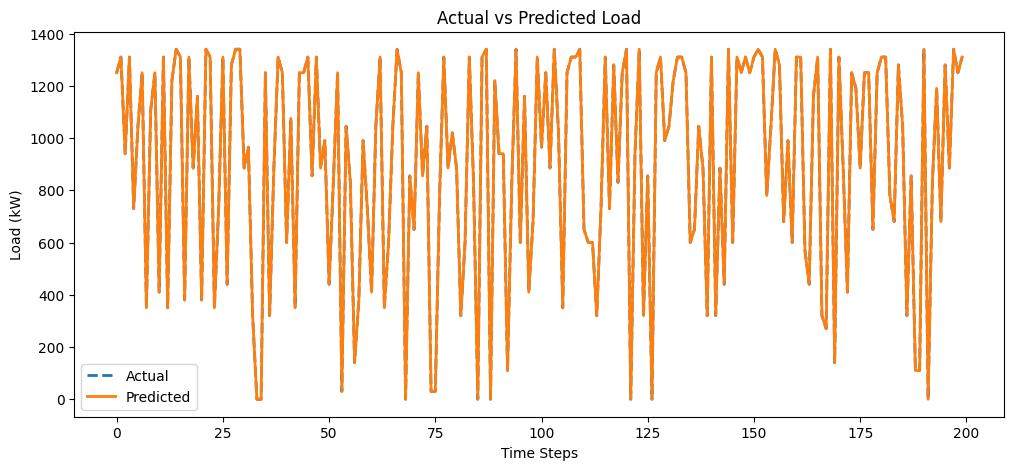

In [65]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:200], label='Actual', linestyle='dashed', linewidth=2)
plt.plot(y_pred_rf[:200], label='Predicted', linewidth=2)

plt.legend()
plt.title("Actual vs Predicted Load (Zoomed View)")
# plt.title("Predicted ")
plt.xlabel("Time Steps")
plt.ylabel("Load (kW)")

plt.show()